In [2]:
import cobra
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [3]:
# Load the model
model = cobra.io.read_sbml_model("../model.xml")

In [3]:
ecoli_model = cobra.io.read_sbml_model("/Users/helenscott/Documents/PhD/Segre-lab/GEM-repos/ecoli/iJO1366.xml")

In [4]:
# Define a minimal media without C or N
minimal_media = {
    "EX_cpd00058_e0": 1000,  # Cu2+_e0
    "EX_cpd00007_e0": 1000,  # O2_e0
    "EX_cpd00971_e0": 1000,  # Na+_e0
    "EX_cpd00063_e0": 1000,  # Ca2+_e0
    "EX_cpd00048_e0": 1000,  # Sulfate_e0
    "EX_cpd10516_e0": 1000,  # fe3_e0
    "EX_cpd00254_e0": 1000,  # Mg_e0
    "EX_cpd00009_e0": 1000,  # Phosphate_e0
    "EX_cpd00205_e0": 1000,  # K+_e0
    "EX_cpd00099_e0": 1000,  # Cl-_e0
    "EX_cpd00030_e0": 1000,  # Mn2+_e0
    "EX_cpd00001_e0": 1000,  # H2O_e0
    "EX_cpd00034_e0": 1000,  # Zn2+_e0
    "EX_cpd00149_e0": 1000,  # Co2+_e0
}

In [5]:
# Define carbon sources to test
c_source = {"Glucose": {"modelseed": "EX_cpd00027_e0", "bigg": "EX_glc__D_e"},
            "Acetate": {"modelseed": "EX_cpd00029_e0", "bigg": "EX_ac_e"},
            "Pyruvate": {"modelseed": "EX_cpd00020_e0", "bigg": "EX_pyr_e"},
            "Succinate": {"modelseed": "EX_cpd00036_e0", "bigg": "EX_succ_e"}}

In [6]:
# Define nitrogen sources to test
n_source = {"Ammonia": {"modelseed": "EX_cpd00013_e0", "bigg": "EX_nh4_e"},
            "Nitrate": {"modelseed": "EX_cpd00209_e0", "bigg": "EX_no3_e"}}

In [22]:
# Make a list to store results
results_list = []

# For each carbon and nitrogen source, and proton limit test growth
p_id = "EX_cpd00067_e0"
for p_limit in [0, 1, 10, 1000]:

    for c_name, c_dict in c_source.items():
        # Extract the modelseed ID for the carbon source
        c_id = c_dict["modelseed"]
        # Find the metabolite for the carbon source
        carbon_metabolite = model.metabolites.get_by_id(c_id[3:])
        # Get the number of carbons in the carbon source
        n_carbons = carbon_metabolite.elements.get("C", 0)

        for n_name, n_dict in n_source.items():
            # Extract the modelseed ID for the nitrogen source
            n_id = n_dict["modelseed"]

            # Create a copy of the minimal media
            media = minimal_media.copy()

            # Add the carbon, nitrogen, and proton sources to the media
            media[c_id] = 60/n_carbons  # Set the carbon source to 60 mM C
            media[n_id] = 1000  # Unlimited nitrogen source
            media[p_id] = p_limit

            # Set the minimal media
            model.medium = media
            
            # Run pFBA
            solution = cobra.flux_analysis.pfba(model)
            
            # Store the results
            results_list.append({
                "Carbon Source": c_name,
                "Nitrogen Source": n_name,
                "Proton Limit": p_limit,
                "Media": media,
                "Growth Rate": solution.fluxes["bio1_biomass"],
                "Fluxes": solution.fluxes
            })

            # Save the fluxes as a JSON file
            solution.fluxes.to_json(f"fluxes_{c_name}_{n_name}_p{p_limit}.json")

# Create a dataframe from the list of results
results = pd.DataFrame(results_list)

In [20]:
results

,Carbon Source,Nitrogen Source,Proton Limit,Media,Growth Rate,Fluxes
0,Glucose,Ammonia,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.673652,rxn02201_c0 0.004336 rxn00351_c0 0...
1,Glucose,Nitrate,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.565758,rxn02201_c0 0.003641 rxn00351_c0 0...
2,Acetate,Ammonia,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.135752,rxn02201_c0 8.737241e-04 rxn00351_c0 ...
3,Acetate,Nitrate,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.000000,rxn02201_c0 0.0 rxn00351_c0 0.0 rx...
4,Pyruvate,Ammonia,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.383121,rxn02201_c0 0.002466 rxn00351_c0 0...
5,Pyruvate,Nitrate,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.282093,rxn02201_c0 0.001816 rxn00351_c0 0...
6,Succinate,Ammonia,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.239864,rxn02201_c0 0.001544 rxn00351_c0 0...
7,Succinate,Nitrate,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.000000,rxn02201_c0 0.0 rxn00351_c0 0.0 rx...
8,Glucose,Ammonia,1,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.673652,rxn02201_c0 0.004336 rxn00351_c0 0...
9,Glucose,Nitrate,1,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.572830,rxn02201_c0 0.003687 rxn00351_c0 0...


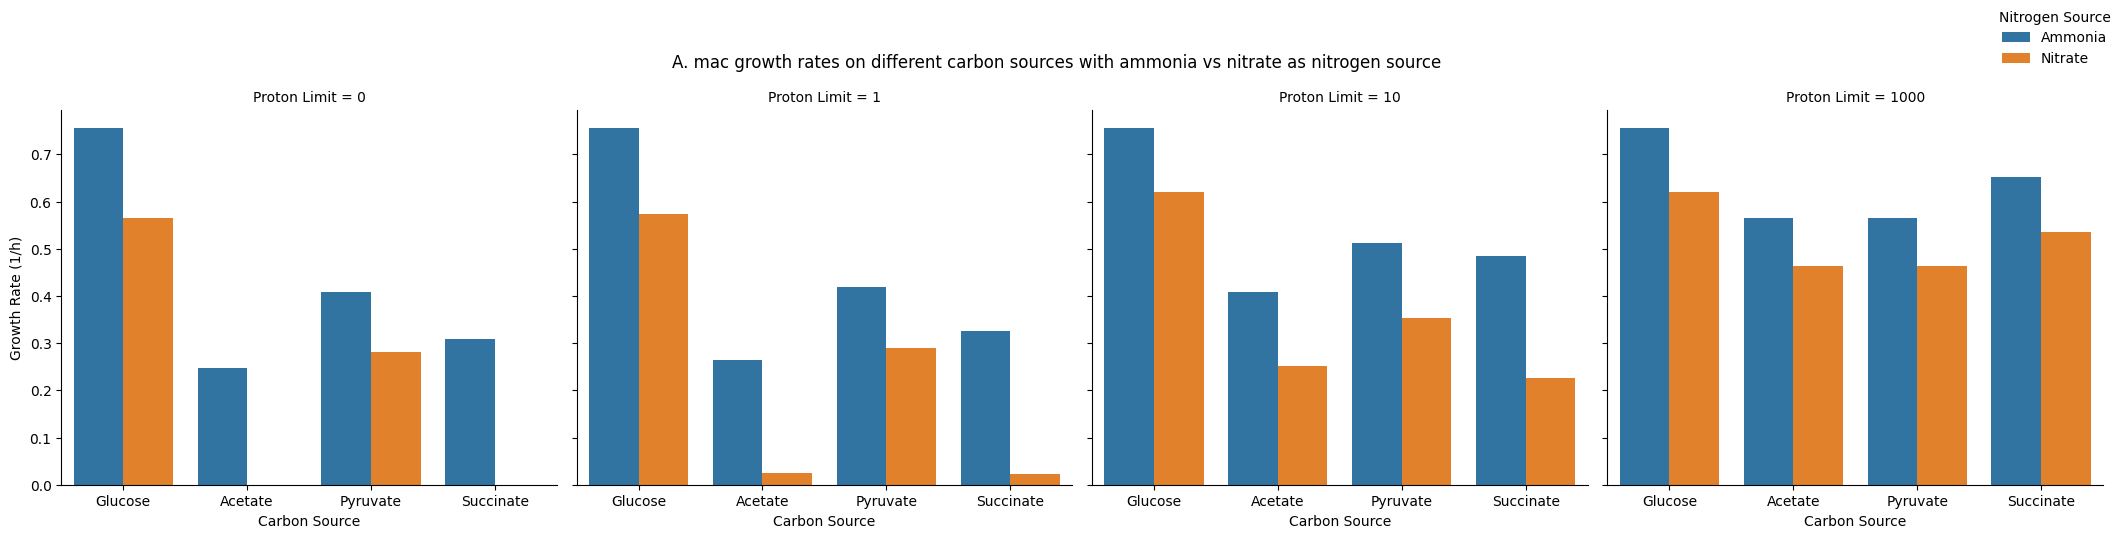

In [23]:
# Plot a series of paired bar charts of growth rates for each carbon source with ammonia vs nitrate as the nitrogen source, with separate charts for each proton limit
g = sns.catplot(
    data=results, kind="bar",
    x="Carbon Source", y="Growth Rate", hue="Nitrogen Source",
    col="Proton Limit",
)
g.fig.suptitle("A. mac growth rates on different carbon sources with ammonia vs nitrate as nitrogen source")
g.set_axis_labels("Carbon Source", "Growth Rate (1/h)")
g.legend.set_title("Nitrogen Source")
# Move the legend to the top right corner
g._legend.set_bbox_to_anchor((1, 1))

plt.tight_layout()
plt.show()

In [11]:
# Parse the 'Fluxes' column to extract the flux values into a dictionary
results['Fluxes_dict'] = results['Fluxes'].apply(lambda x: x.to_dict())

# Group by carbon and nitrogen source
grouped = results.groupby(['Carbon Source', 'Nitrogen Source'])

# Iterate over each group and compare the fluxes
for name, group in grouped:
    # Separate the two proton limit conditions
    limit_0 = group[group['Proton Limit'] == 0].iloc[0]
    limit_1000 = group[group['Proton Limit'] == 1000].iloc[0]

    # Get the flux dictionaries
    fluxes_0 = limit_0['Fluxes_dict']
    fluxes_1000 = limit_1000['Fluxes_dict']

    # Find reactions with different fluxes
    diff_reactions = {rxn: (fluxes_0.get(rxn, 0), fluxes_1000.get(rxn, 0))
                      for rxn in set(fluxes_0) | set(fluxes_1000)
                      if not pd.isna(fluxes_0.get(rxn, 0)) and not pd.isna(fluxes_1000.get(rxn, 0)) and
                         abs(fluxes_0.get(rxn, 0) - fluxes_1000.get(rxn, 0)) > 1e-6}

    if diff_reactions:
        # Create a DataFrame for the differences
        diff_df = pd.DataFrame.from_dict(diff_reactions, orient='index', columns=['Proton Limit 0', 'Proton Limit 1000'])
        diff_df['Difference'] = diff_df['Proton Limit 1000'] - diff_df['Proton Limit 0']

        # Subset the DataFrame to include only reactions that involve protons
        h_e_diff_df = diff_df[diff_df.index.isin([rxn.id for rxn in model.reactions if model.metabolites.cpd00067_e0 in rxn.metabolites])].copy()

        # Add columns for the reaction names and reaction string
        h_e_diff_df['Reaction Name'] = h_e_diff_df.index.map(lambda rxn_id: model.reactions.get_by_id(rxn_id).name)
        h_e_diff_df['Reaction String'] = h_e_diff_df.index.map(lambda rxn_id: model.reactions.get_by_id(rxn_id).build_reaction_string(use_metabolite_names=True))
        # Reorder the columns so they go first with the reaction name, then the reaction string, then the fluxes and difference
        h_e_diff_df = h_e_diff_df[['Reaction Name', 'Reaction String', 'Proton Limit 0', 'Proton Limit 1000', 'Difference']]

        print(f"# Extracellular Proton Flux differences for {name[0]} with {name[1]}:")
        print(f"{h_e_diff_df.to_markdown()}\n")

# Extracellular Proton Flux differences for Acetate with Ammonia:
|                | Reaction Name                                        | Reaction String                                                                      |   Proton Limit 0 |   Proton Limit 1000 |   Difference |
|:---------------|:-----------------------------------------------------|:-------------------------------------------------------------------------------------|-----------------:|--------------------:|-------------:|
| rxn08173_c0    | F(1)-ATPase [c0]                                     | ADP + Phosphate + 4.0 H+ [e0] <=> H2O + ATP + 3.0 H+                                 |     38.3194      |        39.0499      |   0.730507   |
| rxn05618_c0    | manganese transport in via proton symport [c0]       | Mn2+ [e0] + H+ [e0] --> Mn2+ + H+                                                    |      0.000291241 |         0.000717862 |   0.00042662 |
| rxn05209_c0    | TRANS-RXNBWI-115525.ce.maizeexp.NA+_NA+ [c0]   

In [10]:
# Add a reaction for NADH to go into the cell
model.add_boundary(model.metabolites.cpd00004_c0, type="sink")

Reaction identifier,SK_cpd00004_c0
Name,NADH sink
Memory address,0x11e638550
Stoichiometry,cpd00004_c0 <=> NADH <=>
GPR,
Lower bound,-1000.0
Upper bound,1000.0


In [11]:
# Do the same thing I did for Protons, but now for NADH
# Make a list to store results
results_list = []

# For each carbon and nitrogen source, and proton limit test growth
nadh_id = "SK_cpd00004_c0"
for nadh_limit in [0, 1, 10, 100, 1000]:

    for c_name, c_dict in c_source.items():
        # Extract the modelseed ID for the carbon source
        c_id = c_dict["modelseed"]
        # Find the metabolite for the carbon source
        carbon_metabolite = model.metabolites.get_by_id(c_id[3:])
        # Get the number of carbons in the carbon source
        n_carbons = carbon_metabolite.elements.get("C", 0)

        for n_name, n_dict in n_source.items():
            # Extract the modelseed ID for the nitrogen source
            n_id = n_dict["modelseed"]

            # Create a copy of the minimal media
            media = minimal_media.copy()

            # Add the carbon, nitrogen, and proton sources to the media
            media[c_id] = 60/n_carbons  # Set the carbon source to 60 mM C
            media[n_id] = 1000  # Unlimited nitrogen source
            media[nadh_id] = nadh_limit

            # Set the minimal media
            model.medium = media
            
            # Run pFBA
            solution = cobra.flux_analysis.pfba(model)
            
            # Store the results
            results_list.append({
                "Carbon Source": c_name,
                "Nitrogen Source": n_name,
                "NADH Limit": nadh_limit,
                "NADH Sink Bounds": (model.reactions.get_by_id(nadh_id).lower_bound, model.reactions.get_by_id(nadh_id).upper_bound),
                "Media": media,
                "Growth Rate": solution.fluxes["bio1_biomass"],
                "Fluxes": solution.fluxes
            })

# Create a dataframe from the list of results
results = pd.DataFrame(results_list)

SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds 

In [12]:
results

,Carbon Source,Nitrogen Source,NADH Limit,NADH Sink Bounds,Media,Growth Rate,Fluxes
0,Glucose,Ammonia,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.755570,rxn02201_c0 0.004863 rxn00351_c0 0...
1,Glucose,Nitrate,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.565758,rxn02201_c0 0.003641 rxn00351_c0 0...
2,Acetate,Ammonia,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.246669,rxn02201_c0 0.001588 rxn00351_c0 0...
3,Acetate,Nitrate,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.000000,rxn02201_c0 0.0 rxn00351_c0 0.0 rx...
4,Pyruvate,Ammonia,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.409097,rxn02201_c0 0.002633 rxn00351_c0 0...
5,Pyruvate,Nitrate,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.282093,rxn02201_c0 0.001816 rxn00351_c0 0...
6,Succinate,Ammonia,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.308567,rxn02201_c0 0.001986 rxn00351_c0 0...
7,Succinate,Nitrate,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.000000,rxn02201_c0 0.0 rxn00351_c0 0.0 rx...
8,Glucose,Ammonia,1,"(-1, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.756604,rxn02201_c0 0.004870 rxn00351_c0 0...
9,Glucose,Nitrate,1,"(-1, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.566763,rxn02201_c0 0.003648 rxn00351_c0 0...


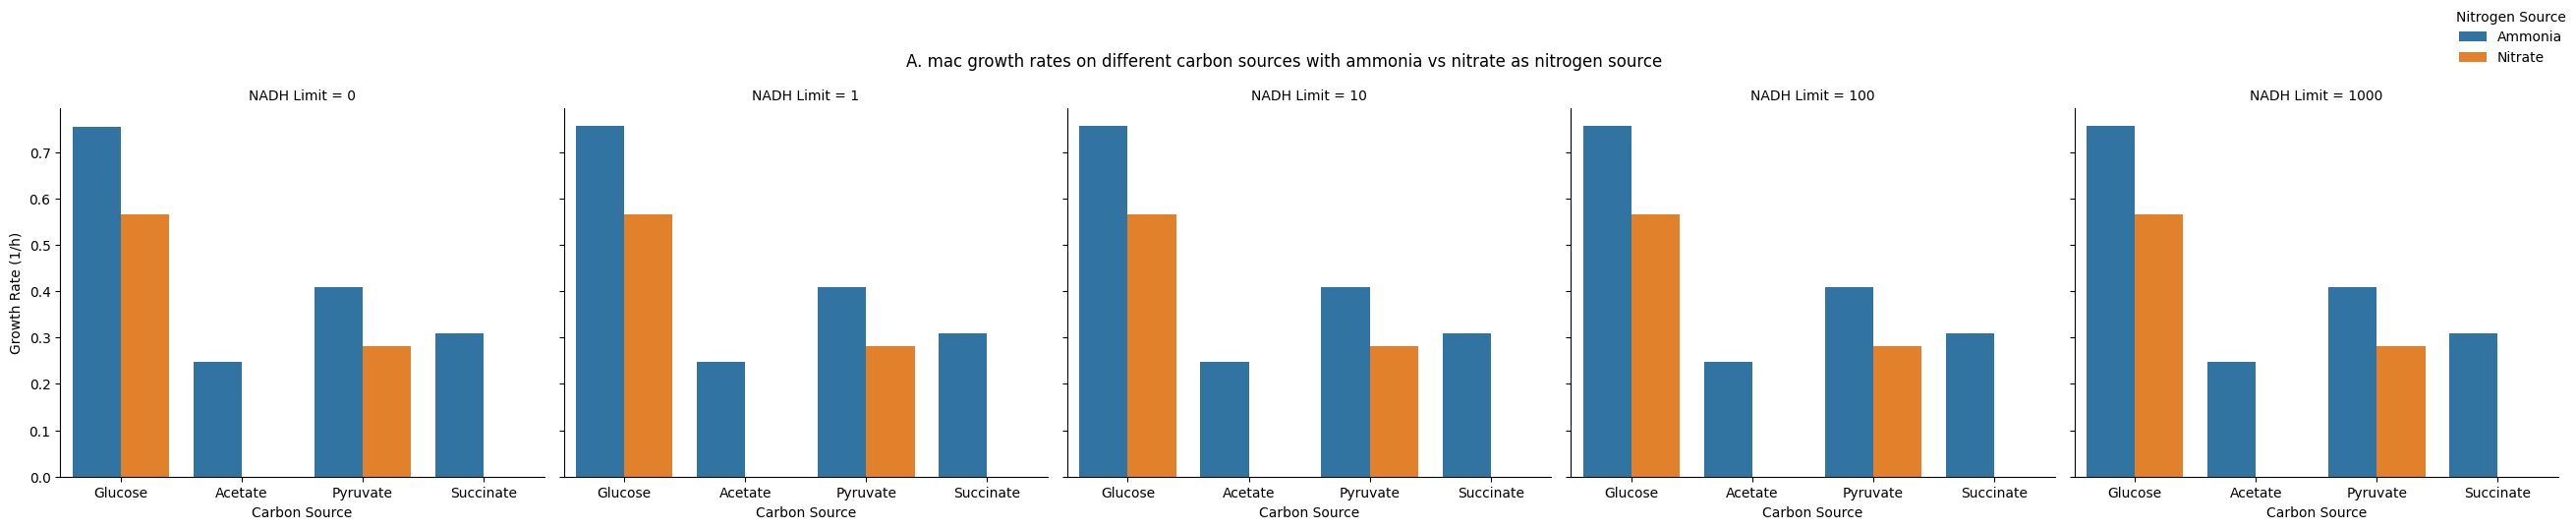

In [13]:
# Plot a series of paired bar charts of growth rates for each carbon source with ammonia vs nitrate as the nitrogen source, with separate charts for each proton limit
g = sns.catplot(
    data=results, kind="bar",
    x="Carbon Source", y="Growth Rate", hue="Nitrogen Source",
    col="NADH Limit",
)
g.fig.suptitle("A. mac growth rates on different carbon sources with ammonia vs nitrate as nitrogen source")
g.set_axis_labels("Carbon Source", "Growth Rate (1/h)")
g.legend.set_title("Nitrogen Source")
# Move the legend to the top right corner
g._legend.set_bbox_to_anchor((1, 1))

plt.tight_layout()
plt.show()

## E. coli

In [12]:
ecoli_minimal_media = {
 'EX_co2_e': 1000.0,
 'EX_cobalt2_e': 1000.0,
 'EX_h2o_e': 1000.0,
 'EX_k_e': 1000.0,
 'EX_cu2_e': 1000.0,
 'EX_mg2_e': 1000.0,
 'EX_mn2_e': 1000.0,
 'EX_mobd_e': 1000.0,
 'EX_na1_e': 1000.0,
 'EX_ca2_e': 1000.0,
 'EX_cbl1_e': 0.01,
 'EX_ni2_e': 1000.0,
 'EX_o2_e': 1000.0,
 'EX_cl_e': 1000.0,
 'EX_pi_e': 1000.0,
 'EX_zn2_e': 1000.0,
 'EX_sel_e': 1000.0,
 'EX_slnt_e': 1000.0,
 'EX_so4_e': 1000.0,
 'EX_tungs_e': 1000.0,
 'EX_fe2_e': 1000.0,
 'EX_fe3_e': 1000.0
 }

In [13]:
# Make a list to store results
ecoli_results_list = []

# For each carbon and nitrogen source, and proton limit test growth
p_id = "EX_h_e"
for p_limit in [0, 1000]:

    for c_name, c_dict in c_source.items():
        # Extract the modelseed ID for the carbon source
        c_id = c_dict["bigg"]
        # Find the metabolite for the carbon source
        carbon_metabolite = ecoli_model.metabolites.get_by_id(c_id[3:])
        # Get the number of carbons in the carbon source
        n_carbons = carbon_metabolite.elements.get("C", 0)

        for n_name, n_dict in n_source.items():
            # Extract the modelseed ID for the nitrogen source
            n_id = n_dict["bigg"]

            # Create a copy of the minimal media
            media = ecoli_minimal_media.copy()

            # Add the carbon, nitrogen, and protons to the medium
            media[c_id] = 60/n_carbons  # Set the carbon source to 60 mM C
            media[n_id] = 1000
            media[p_id] = p_limit
            
            # Set the minimal media
            ecoli_model.medium = media
            
            # Run pFBA
            solution = cobra.flux_analysis.pfba(ecoli_model)
            
            # Store the results
            ecoli_results_list.append({
                "Carbon Source": c_name,
                "Nitrogen Source": n_name,
                "Proton Limit": p_limit,
                "Media": media,
                "Growth Rate": solution.fluxes["BIOMASS_Ec_iJO1366_core_53p95M"],
                "Fluxes": solution.fluxes
            })

# Create a dataframe from the list of results
ecoli_results = pd.DataFrame(ecoli_results_list)

In [14]:
ecoli_results

,Carbon Source,Nitrogen Source,Proton Limit,Media,Growth Rate,Fluxes
0,Glucose,Ammonia,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.982372,EX_cm_e 0.000000 EX_cmp_e 0.0...
1,Glucose,Nitrate,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.779840,EX_cm_e 0.000000 EX_cmp_e 0.0...
2,Acetate,Ammonia,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.534681,EX_cm_e 0.000000 EX_cmp_e 0.0...
3,Acetate,Nitrate,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.386570,EX_cm_e 0.000000 EX_cmp_e 0.0...
4,Pyruvate,Ammonia,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.617273,EX_cm_e 0.000000 EX_cmp_e 0.0...
5,Pyruvate,Nitrate,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.448744,EX_cm_e 0.000000 EX_cmp_e 0.0...
6,Succinate,Ammonia,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.521589,EX_cm_e 0.000000 EX_cmp_e 0.0...
7,Succinate,Nitrate,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.374848,EX_cm_e 0.000000 EX_cmp_e 0.0...
8,Glucose,Ammonia,1000,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.982372,EX_cm_e 0.000000 EX_cmp_e 0.0...
9,Glucose,Nitrate,1000,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.849220,EX_cm_e 0.000000 EX_cmp_e 0.0...


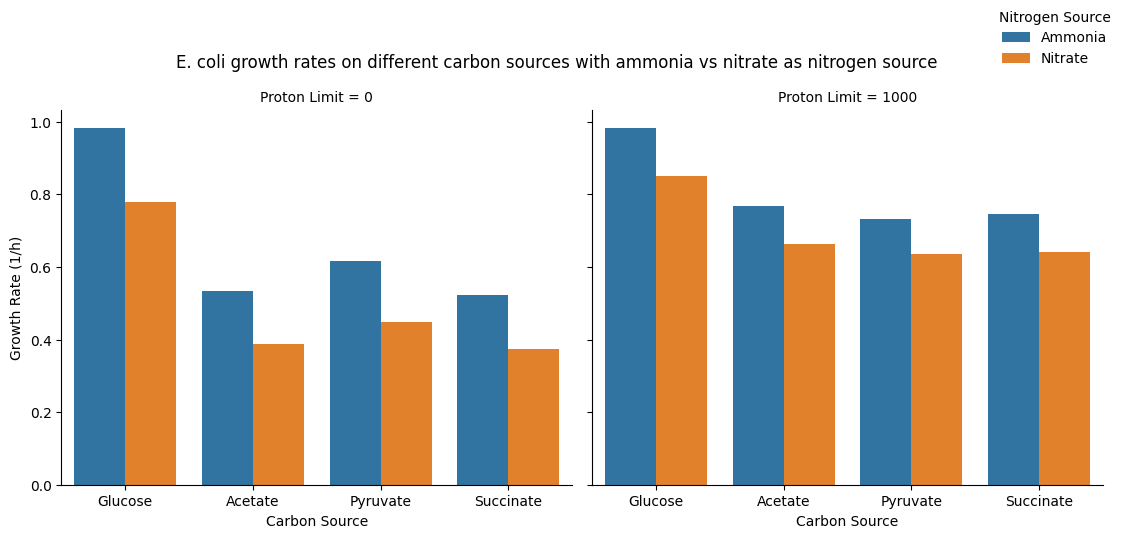

In [15]:
# Plot a paired bar chart of growth rates for each carbon source with ammonia vs nitrate as the nitrogen source
g = sns.catplot(
    data=ecoli_results, kind="bar",
    x="Carbon Source", y="Growth Rate", hue="Nitrogen Source",
    col="Proton Limit",
)
g.fig.suptitle("E. coli growth rates on different carbon sources with ammonia vs nitrate as nitrogen source")
g.set_axis_labels("Carbon Source", "Growth Rate (1/h)")
g.legend.set_title("Nitrogen Source")
# Move the legend to the top right corner
g._legend.set_bbox_to_anchor((1, 1))

plt.tight_layout()
plt.show()

# Proton-Dependent Transporters

In [16]:
# Get the metabolite object for extracellular protons
h_e_met = model.metabolites.cpd00067_e0

# Print a markdown formatted table for all of the reactions that involve extracellular protons
# Print the header
print("||ID|Name|Bounds|Reaction|")
print("|---|---|---|---|---|")
# Loop through the reactions and print the ID, name, bounds, and reaction string
for i, r in enumerate(h_e_met.reactions):
    print(f"|{i+1}|{r.id}|{r.name}|{r.bounds}|{r.build_reaction_string(use_metabolite_names=True)}|")

||ID|Name|Bounds|Reaction|
|---|---|---|---|---|
|1|rxn05671_c0|D-xylose transport in via proton symport [c0]|(-1000.0, 1000.0)|H+ [e0] + Xylose [e0] <=> H+ + Xylose|
|2|rxn08350_c0|D-lactate transport via proton symport (periplasm) [c0]|(-1000.0, 1000.0)|H+ [e0] + D-Lactate [e0] <=> H+ + D-Lactate|
|3|rxn05527_c0|TRANS-RXN-199.ce [c0]|(-1000.0, 1000.0)|H+ [e0] + Cytosine [e0] <=> H+ + Cytosine|
|4|rxn05559_c0|formate transport in via proton symport [c0]|(-1000.0, 1000.0)|Formate [e0] + H+ [e0] <=> Formate + H+|
|5|rxn14420_c0|cytochrome-bd reductase (menaquinol: 2 protons) [c0]|(0.0, 1000.0)|Menaquinol 8 + Cytochrome-bd-ox --> 2.0 H+ [e0] + Menaquinone 8 + Cytochrome-bd-red|
|6|rxn05514_c0|calcium transport in/out via proton antiporter [c0]|(-1000.0, 1000.0)|Ca2+ + H+ [e0] <=> Ca2+ [e0] + H+|
|7|rxn05200_c0|Transport of thymidine, extracellular [c0]|(-1000.0, 1000.0)|H+ [e0] + Thymidine [e0] <=> H+ + Thymidine|
|8|rxn05573_c0|D-glucose transport in via proton symport [c0]|(0.0, 1000.0

In [17]:
# Run pFBA 